<a href="https://colab.research.google.com/github/SaakshiPandey/Air-Quality-Analyser/blob/main/air_quality_analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)


Saving AirQualityUCI.csv to AirQualityUCI (1).csv


## Data Preprocessing

In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO_Bin,CO_Category
0,33.0,18.0,2.6,1360.0,-200.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,3,High
1,33.0,19.0,2.0,1292.0,-200.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2,Medium
2,33.0,20.0,2.2,1402.0,-200.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2,High
3,33.0,21.0,2.2,1376.0,-200.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2,High
4,33.0,22.0,1.6,1272.0,-200.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2,Medium


In [ ]:
import numpy as np
import pandas as pd

# Replace missing tokens with NaN
df = df.replace(['?', 'Nan', 'nan', 'null', 'NULL', 'NA', 'na', 1, np.nan], np.nan)

# Drop columns with more than 50% missing values
df = df.loc[:, df.isnull().mean() < 0.5]

# Fill numeric columns with median
for col in df.select_dtypes(include=[np.number]).columns:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("✅ Missing values handled successfully.")
print(df.isnull().sum())



✅ Missing values handled successfully.
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO_Bin           0
CO_Category      0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])




In [ ]:
print("➡️ Original data shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


➡️ Original data shape: (9357, 17)

Missing values per column:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO_Bin           0
CO_Category      0
dtype: int64

Data types:
Date              float64
Time              float64
CO(GT)            float64
PT08.S1(CO)       float64
NMHC(GT)          float64
C6H6(GT)          float64
PT08.S2(NMHC)     float64
NOx(GT)           float64
PT08.S3(NOx)      float64
NO2(GT)           float64
PT08.S4(NO2)      float64
PT08.S5(O3)       float64
T                 float64
RH                float64
AH                float64
CO_Bin            float64
CO_Category      category
dtype: object

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO_Bin,CO_Category
0,33.0,18.0,2.6,1360.0,-200.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,3.0,High
1,33.0,19.0,2.0,1292.0,-200.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2.0,Medium
2,33.0,20.0,2.2,1402.0,-200.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2.0,High
3,33.0,21.0,2.2,1376.0,-200.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2.0,High
4,33.0,22.0,1.6,1272.0,-200.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2.0,Medium


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalization
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[df_norm.select_dtypes(include=[np.number]).columns] = scaler.fit_transform(
    df_norm.select_dtypes(include=[np.number])
)

# Standardization
std_scaler = StandardScaler()
df_std = df.copy()
df_std[df_std.select_dtypes(include=[np.number]).columns] = std_scaler.fit_transform(
    df_std.select_dtypes(include=[np.number])
)

print("Normalization and Standardization done.")


Normalization and Standardization done.


In [ ]:
# Remove duplicate rows
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


Before removing duplicates: (9357, 17)
After removing duplicates: (9356, 17)


In [ ]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers treated.")



Outliers treated.


In [ ]:
# Convert numeric-looking strings to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

if 'Datetime' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')




/tmp/ipython-input-3780684330.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO_Bin,CO_Category
0,33.0,18.0,2.6,1360.0,-200.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,3.0,High
1,33.0,19.0,2.0,1292.0,-200.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2.0,Medium
2,33.0,20.0,2.2,1402.0,-200.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2.0,High
3,33.0,21.0,2.2,1376.0,-200.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2.0,High
4,33.0,22.0,1.6,1272.0,-200.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2.0,Medium


In [ ]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])
selector = VarianceThreshold(threshold=0.01)
numeric_selected = numeric_df.loc[:, selector.fit(numeric_df).get_support()]

# Correlation-based feature selection
corr_matrix = numeric_selected.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
numeric_selected = numeric_selected.drop(columns=to_drop, errors='ignore')

df_selected = pd.concat([numeric_selected, df.select_dtypes(exclude=[np.number])], axis=1)

print("Feature selection done. Final shape:", df_selected.shape)


Feature selection done. Final shape: (9356, 12)


## Linear Regression

In [ ]:

if 'CO(GT)' in df.columns:
    df['CO_Bin'] = pd.cut(df['CO(GT)'], bins=5, labels=False)



In [ ]:
from sklearn.model_selection import train_test_split

if 'CO(GT)' in df.columns:
    X = df.drop(columns=['CO(GT)'])
    y = df['CO(GT)']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Training set shape:", X_train.shape)
    print("Testing set shape:", X_test.shape)


Training set shape: (7484, 16)
Testing set shape: (1872, 16)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [ ]:

if 'CO(GT)' in df.columns:
    X = df.drop(columns=['CO(GT)'])
    y = df['CO(GT)']
else:
    raise ValueError("Target column 'CO(GT)' not found. Please check dataset columns.")


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)



Training set: (7484, 16)
Testing set: (1872, 16)


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Intercept:", lr.intercept_)
print("Number of coefficients:", len(lr.coef_))


Intercept: -1.349893137483609
Number of coefficients: 17


In [ ]:
y_pred = lr.predict(X_test)



In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")



Mean Squared Error (MSE): 0.2420
Root Mean Squared Error (RMSE): 0.4919
Mean Absolute Error (MAE): 0.4154
R² Score: 0.9469


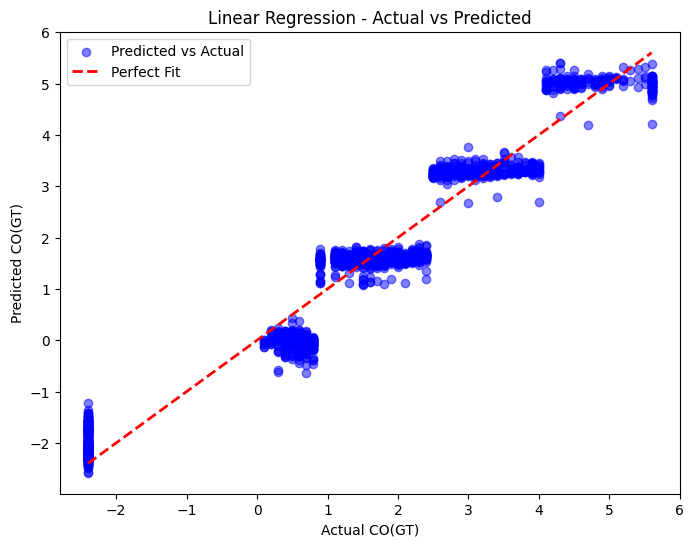

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()



## Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# 1. One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Define model and cross-validation
lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Cross-validation with numeric features only
cv_scores = cross_val_score(lr, X_encoded, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard Deviation of R²:", np.std(cv_scores))


Cross-validation R² scores: [0.94689901 0.9477603  0.94925156 0.94263284 0.94633846]
Mean R²: 0.9465764326559455
Standard Deviation of R²: 0.0022031983230181274


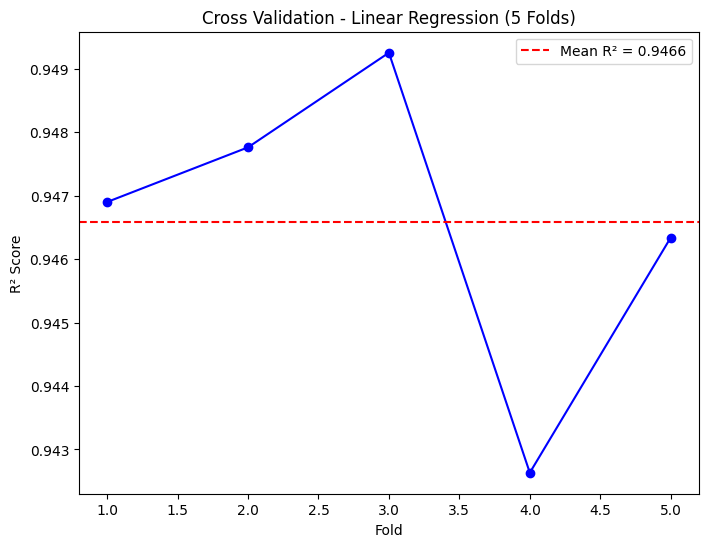

In [ ]:
# Plot cross-validation R² scores
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cv_scores)+1), cv_scores, marker='o', linestyle='-', color='blue')
plt.axhline(y=np.mean(cv_scores), color='red', linestyle='--', label=f"Mean R² = {np.mean(cv_scores):.4f}")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("Cross Validation - Linear Regression (5 Folds)")
plt.legend()
plt.show()


## Performance Metrics

In [ ]:
# Fit the model again
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Adjusted R²
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R² Score: {adj_r2:.4f}")


Mean Squared Error (MSE): 0.2420
Root Mean Squared Error (RMSE): 0.4919
Mean Absolute Error (MAE): 0.4154
R² Score: 0.9469
Adjusted R² Score: 0.9464


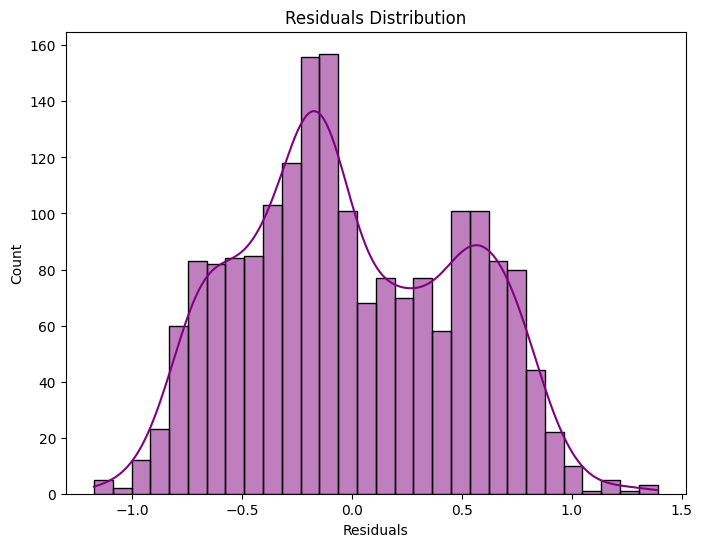

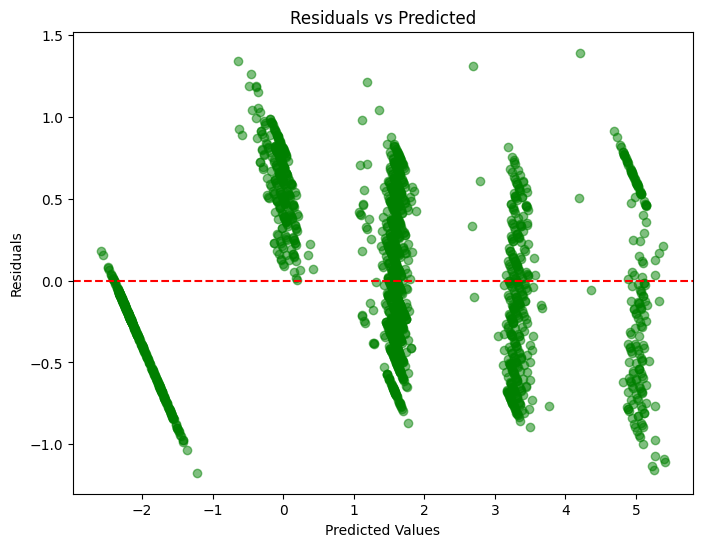

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.xlabel("Residuals")
plt.title("Residuals Distribution")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()



## Linear Regression for Multiple Values

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

print("Intercept:", mlr.intercept_)


Intercept: -1.349893137483609


In [ ]:
mlr = LinearRegression()
mlr.fit(X_encoded, y)

# Create DataFrame of coefficients
coeff_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": mlr.coef_
}).sort_values(by="Coefficient", ascending=False)

coeff_df


,Feature,Coefficient
14,CO_Bin,1.629087e+00
16,CO_Category_High,9.029042e-02
15,CO_Category_Medium,5.154052e-02
4,C6H6(GT),3.809269e-02
11,T,2.706764e-03
8,NO2(GT),1.244722e-03
6,NOx(GT),6.920963e-04
7,PT08.S3(NOx),2.994496e-04
9,PT08.S4(NO2),2.847458e-04
3,NMHC(GT),-8.361367e-16


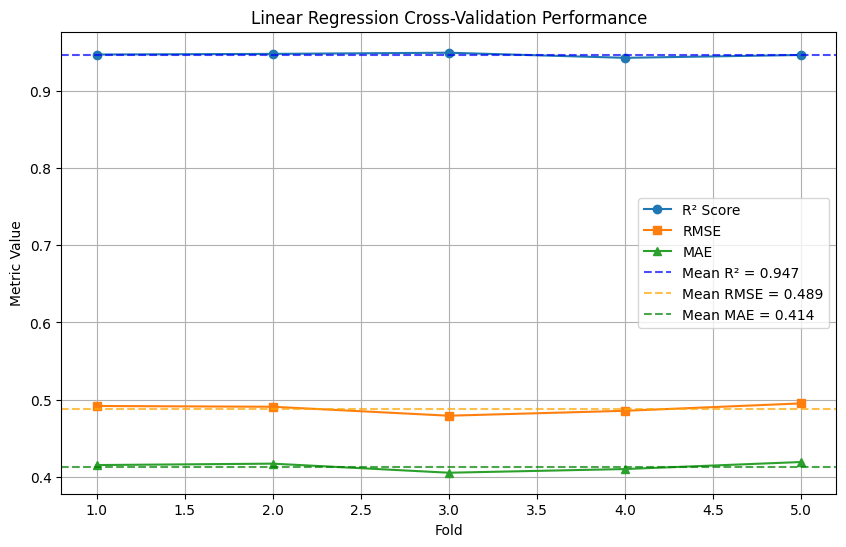

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Use encoded features
X_num = X_encoded.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores, rmse_scores, mae_scores = [], [], []

for train_idx, test_idx in kf.split(X_num):
    X_train_cv, X_test_cv = X_num.iloc[train_idx], X_num.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train_cv, y_train_cv)
    y_pred_cv = model.predict(X_test_cv)

    r2_scores.append(r2_score(y_test_cv, y_pred_cv))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)))
    mae_scores.append(mean_absolute_error(y_test_cv, y_pred_cv))

# --- Plot ---
plt.figure(figsize=(10,6))
plt.plot(range(1, 6), r2_scores, marker='o', linestyle='-', label='R² Score')
plt.plot(range(1, 6), rmse_scores, marker='s', linestyle='-', label='RMSE')
plt.plot(range(1, 6), mae_scores, marker='^', linestyle='-', label='MAE')

# Add mean lines
plt.axhline(np.mean(r2_scores), color='blue', linestyle='--', alpha=0.7, label=f"Mean R² = {np.mean(r2_scores):.3f}")
plt.axhline(np.mean(rmse_scores), color='orange', linestyle='--', alpha=0.7, label=f"Mean RMSE = {np.mean(rmse_scores):.3f}")
plt.axhline(np.mean(mae_scores), color='green', linestyle='--', alpha=0.7, label=f"Mean MAE = {np.mean(mae_scores):.3f}")

plt.xlabel("Fold")
plt.ylabel("Metric Value")
plt.title("Linear Regression Cross-Validation Performance")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
y_pred_mlr = mlr.predict(X_test)

r2 = r2_score(y_test, y_pred_mlr)
adj_r2 = 1 - (1-r2)*(X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1)

print(f"R² Score: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")



R² Score: 0.9472
Adjusted R²: 0.9467


In [ ]:
if 'CO(GT)' in df.columns:
    df['CO_Category'] = pd.qcut(df['CO(GT)'], q=3, labels=["Low", "Medium", "High"])

    X_class = df.drop(columns=['CO(GT)', 'CO_Category'])
    y_class = df['CO_Category']
else:
    raise ValueError("Target column 'CO(GT)' not found in dataset.")



In [ ]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Training set:", X_train_c.shape)
print("Testing set:", X_test_c.shape)



Training set: (7484, 15)
Testing set: (1872, 15)


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_c)

print("Training Accuracy:", log_reg.score(X_train_c, y_train_c))
print("Testing Accuracy:", log_reg.score(X_test_c, y_test_c))


Training Accuracy: 0.9011223944414751
Testing Accuracy: 0.8985042735042735


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler

# Predictions
y_pred_c = log_reg.predict(X_test_c)

print("Classification Report:\n", classification_report(y_test_c, y_pred_c))





Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.87      0.90       622
         Low       0.98      0.91      0.95       648
      Medium       0.81      0.91      0.85       602

    accuracy                           0.90      1872
   macro avg       0.90      0.90      0.90      1872
weighted avg       0.90      0.90      0.90      1872



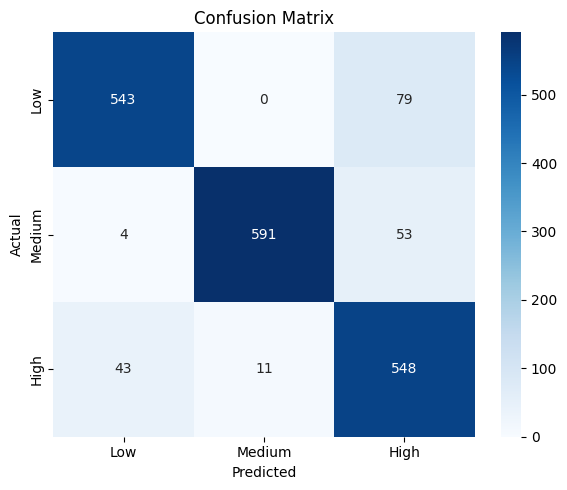

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



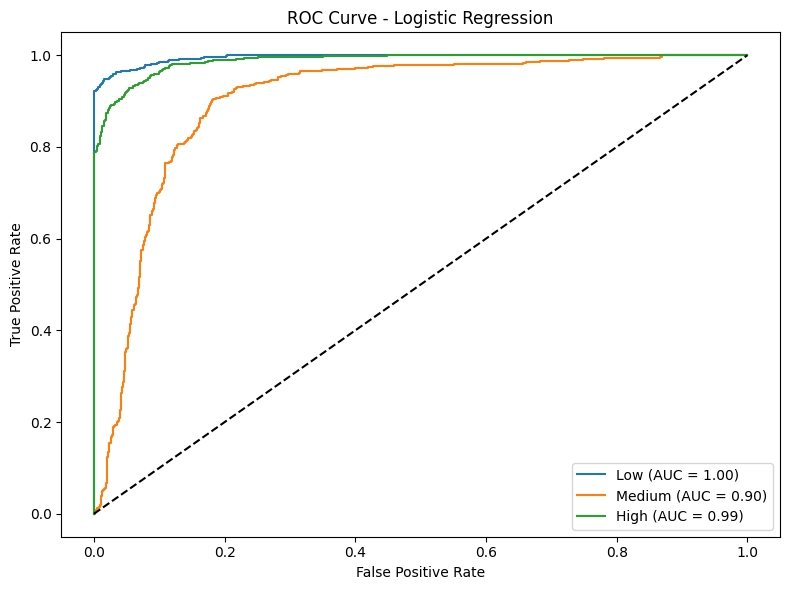

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# One-vs-Rest Logistic Regression
ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
y_train_bin = label_binarize(y_train_c, classes=["Low","Medium","High"])
y_test_bin = label_binarize(y_test_c, classes=["Low","Medium","High"])

ovr.fit(X_train_c_scaled, y_train_bin)
y_score = ovr.decision_function(X_test_c_scaled)

# ROC Curves
fpr, tpr, roc_auc = {}, {}, {}
classes = ["Low","Medium","High"]

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    plt.plot(fpr[cls], tpr[cls], label=f"{cls} (AUC = {roc_auc[cls]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

### **PCA**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



In [ ]:
# Standardize the features before PCA
X = df.select_dtypes(include=np.number)

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of scaled data:", X_scaled.shape)



Shape of scaled data: (9356, 16)


In [ ]:
# Apply PCA to reduce to 3 dimensions
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create a DataFrame for PCA components
pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Target'] = y.reset_index(drop=True)

# Display first few rows
pca_df_3d.head()


,PC1,PC2,PC3,Target
0,1.563050,-0.517390,0.644872,2.6
1,0.357051,-0.249030,0.514112,2.0
2,0.745635,-0.378614,0.784283,2.2
3,1.003441,-0.428145,0.960253,2.2
4,0.231959,-0.422402,0.855961,1.6


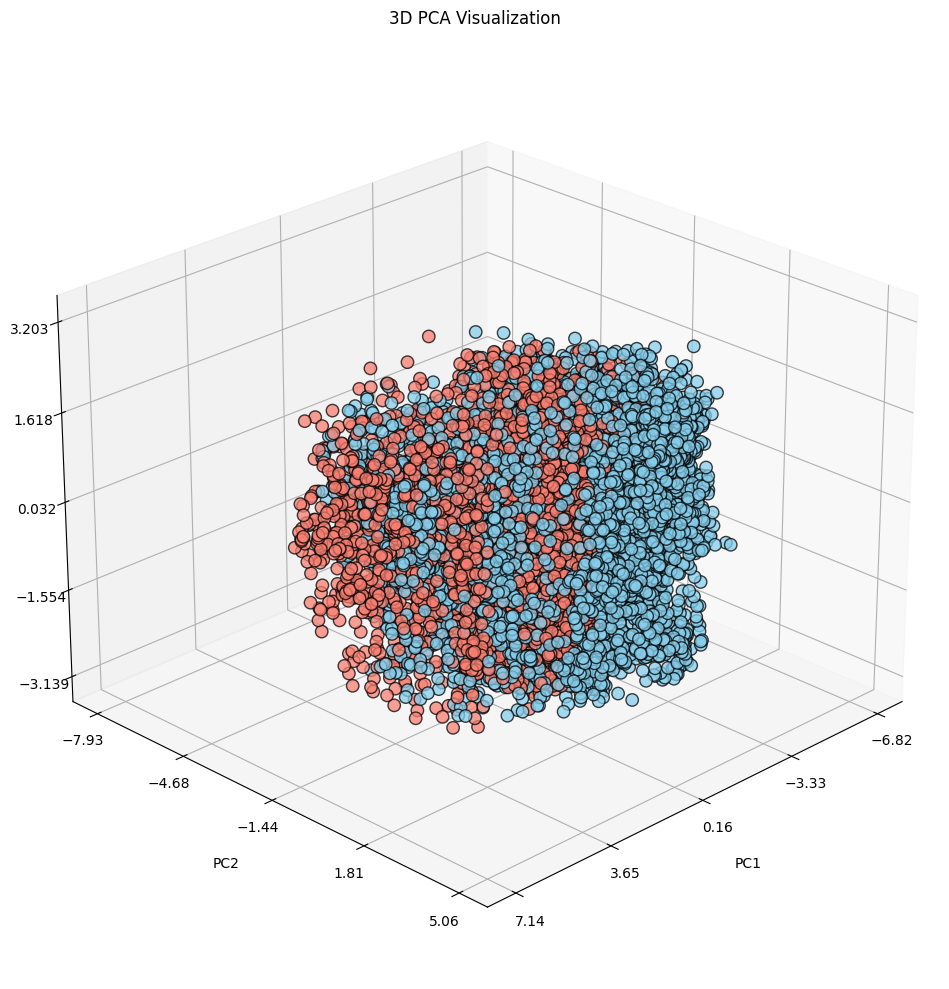

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define 2 colors
colors = ['skyblue', 'salmon']

# Map each class to one of the two colors
unique_labels = np.unique(pca_df_3d['Target'])
color_map = {label: colors[i % 2] for i, label in enumerate(unique_labels)}

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for label in unique_labels:
    subset = pca_df_3d[pca_df_3d['Target'] == label]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        color=color_map[label],
        s=80,
        alpha=0.75,
        edgecolor='black',
        label=label
    )

# Axis labels and title
ax.set_xlabel('PC1', labelpad=15)
ax.set_ylabel('PC2', labelpad=15)
ax.set_zlabel('PC3', labelpad=15)
ax.set_title('3D PCA Visualization', pad=20)

# Optional: reduce side ticks for clarity
ax.set_xticks(np.linspace(pca_df_3d['PC1'].min(), pca_df_3d['PC1'].max(), 5))
ax.set_yticks(np.linspace(pca_df_3d['PC2'].min(), pca_df_3d['PC2'].max(), 5))
ax.set_zticks(np.linspace(pca_df_3d['PC3'].min(), pca_df_3d['PC3'].max(), 5))

# Grid, legend, viewing angle
ax.grid(True, linestyle='--', alpha=0.5)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()


In [ ]:
# Check how much variance the first 3 components explain
print("Explained variance ratio:", pca_3d.explained_variance_ratio_)
print("Total variance explained by 3 components:",
      round(sum(pca_3d.explained_variance_ratio_)*100, 2), "%")


Explained variance ratio: [0.4092183  0.23801905 0.10025422]
Total variance explained by 3 components: 74.75 %


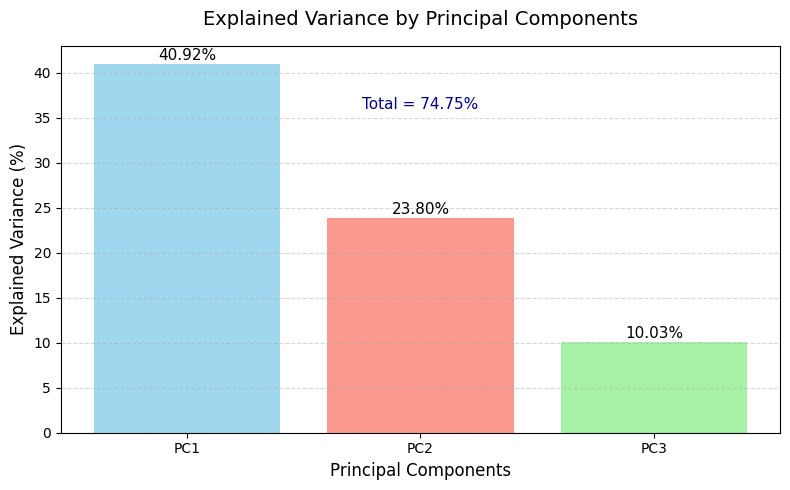

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Explained variance ratios for the 3 components
var_ratios = pca_3d.explained_variance_ratio_
components = ['PC1', 'PC2', 'PC3']

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(components, var_ratios * 100, color=['skyblue', 'salmon', 'lightgreen'], alpha=0.8)

# Add percentage labels on top of bars
for bar, var in zip(bars, var_ratios):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{var*100:.2f}%',
             ha='center', fontsize=11, color='black')

# Labels and title
plt.title('Explained Variance by Principal Components', fontsize=14, pad=15)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)

# Optional: show total variance on plot
total_var = sum(var_ratios) * 100
plt.text(1, max(var_ratios)*100 - 5, f'Total = {total_var:.2f}%',
         ha='center', fontsize=11, color='darkblue')

# Neat layout
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Naive Bayes**

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Using PCA-transformed data for training
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_3d, y, test_size=0.2, random_state=42
)


In [ ]:
# Check your target distribution
print(y.describe())

# Convert target to categorical bins (3 classes)
y_binned = pd.cut(y, bins=3, labels=['Low', 'Medium', 'High'])

# Confirm the conversion
print(y_binned.value_counts())



count    9356.000000
mean        1.322274
std         2.116807
min        -2.400000
25%         0.600000
50%         1.500000
75%         2.600000
max         5.600000
Name: CO(GT), dtype: float64
CO(GT)
Medium    5767
High      1829
Low       1760
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_3d, y_binned, test_size=0.2, random_state=42
)


In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

In [ ]:
y_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred)*100))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Naive Bayes Accuracy: 87.93%

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.81      0.86       375
         Low       0.90      0.72      0.80       354
      Medium       0.86      0.95      0.91      1143

    accuracy                           0.88      1872
   macro avg       0.89      0.83      0.85      1872
weighted avg       0.88      0.88      0.88      1872



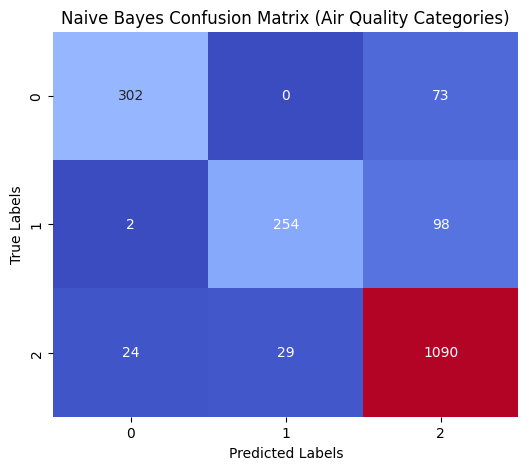

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Naive Bayes Confusion Matrix (Air Quality Categories)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


### **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np



In [ ]:
# Initialize SVM classifier
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)



SVC(random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test)



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9012
Confusion Matrix:
 [[ 337    1   37]
 [   0  286   68]
 [  40   39 1064]]
Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.90      0.90       375
         Low       0.88      0.81      0.84       354
      Medium       0.91      0.93      0.92      1143

    accuracy                           0.90      1872
   macro avg       0.89      0.88      0.89      1872
weighted avg       0.90      0.90      0.90      1872



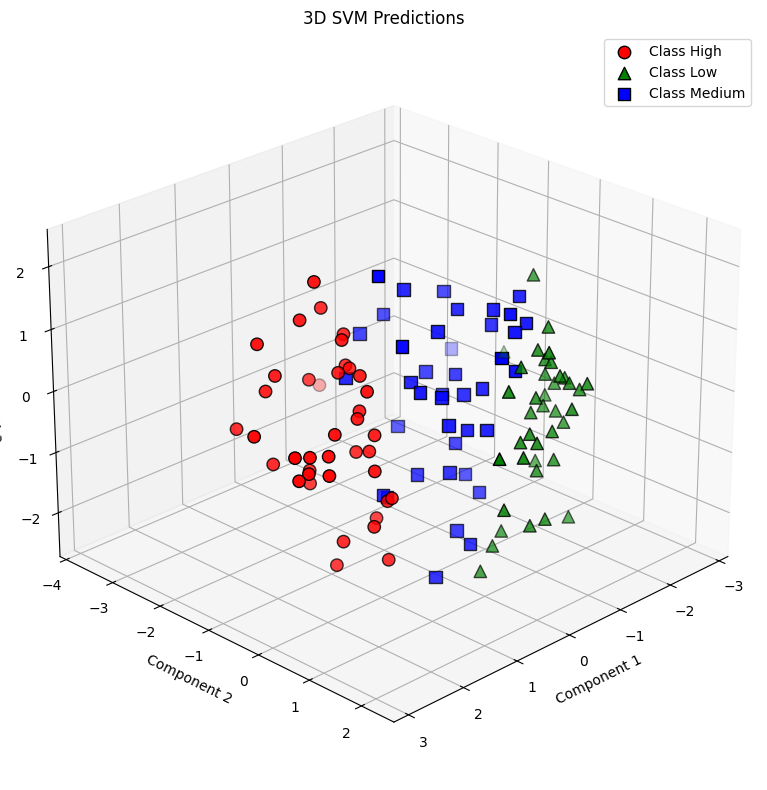

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Scale first 3 components
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[:, :3])
X_test_scaled = scaler.transform(X_test[:, :3])

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

sample_indices = []
for cls in np.unique(y_pred):
    idx = np.where(y_pred == cls)[0]
    if len(idx) > 20:
        idx = np.random.choice(idx, 40, replace=False)
    sample_indices.extend(idx)
sample_indices = np.array(sample_indices)

X_plot = X_test_scaled[sample_indices]
y_plot = y_pred[sample_indices]

# 3D scatter plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

classes = np.unique(y_plot)
colors = ['r', 'g', 'b']  # add more if needed
markers = ['o', '^', 's']

for cls, color, marker in zip(classes, colors, markers):
    idx = np.where(y_plot == cls)
    ax.scatter(X_plot[idx,0], X_plot[idx,1], X_plot[idx,2],
               c=color, marker=marker, s=80, edgecolors='k', label=f'Class {cls}')

ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.set_title('3D SVM Predictions')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()


###Hierarchical Clustering

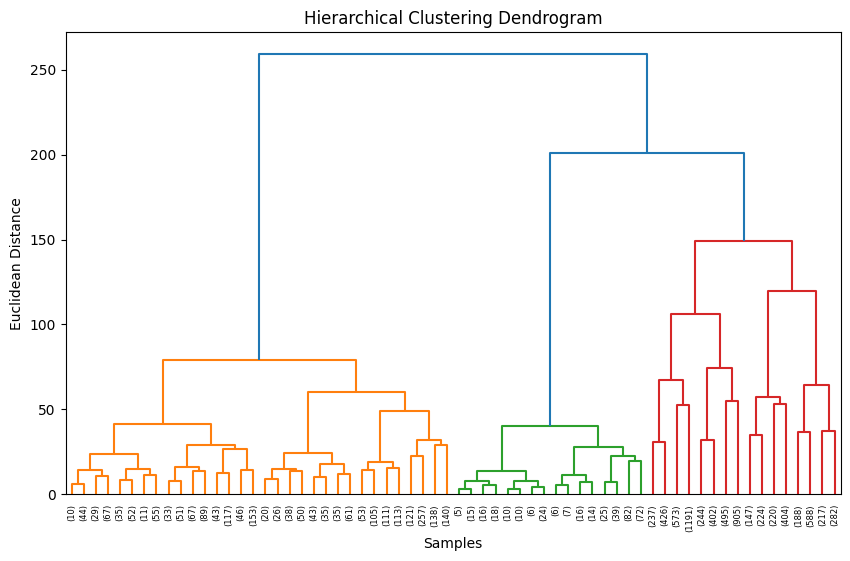

,HC_Cluster
0,0
1,0
2,0
3,0
4,0


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# Select numerical features
X = df.select_dtypes(include=np.number)
X_scaled = StandardScaler().fit_transform(X)

# Perform hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

# Cut dendrogram into clusters
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels = hc.fit_predict(X_scaled)
df['HC_Cluster'] = labels
df[['HC_Cluster']].head()


###K-Means

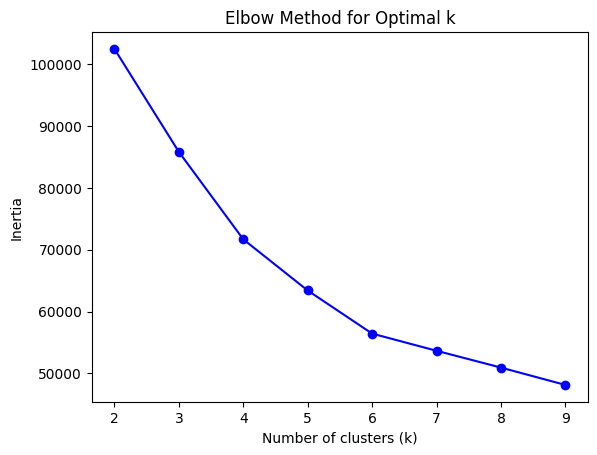

,KMeans_Cluster
0,2
1,0
2,2
3,2
4,0


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

inertia = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Apply KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
df[['KMeans_Cluster']].head()


###Cluster Evaluation

Silhouette Score (DBSCAN): 0.3443


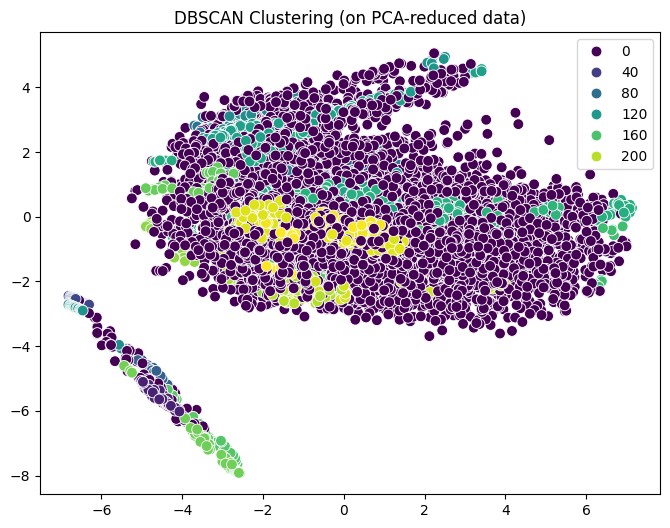

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Run DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_pca)

# Filter out noise (-1 label)
mask = labels != -1
if len(set(labels)) > 1:
    sil_score = silhouette_score(X_pca[mask], labels[mask])
    print(f"Silhouette Score (DBSCAN): {sil_score:.4f}")
else:
    print("DBSCAN could not form meaningful clusters (all noise).")

# Plot the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='viridis', s=60)
plt.title('DBSCAN Clustering (on PCA-reduced data)')
plt.show()


###Decision Tree Algorithm

Accuracy: 0.9508371927324546
              precision    recall  f1-score   support

        High       0.91      0.89      0.90       577
         Low       1.00      0.95      0.98       513
      Medium       0.95      0.97      0.96      1717

    accuracy                           0.95      2807
   macro avg       0.95      0.94      0.95      2807
weighted avg       0.95      0.95      0.95      2807



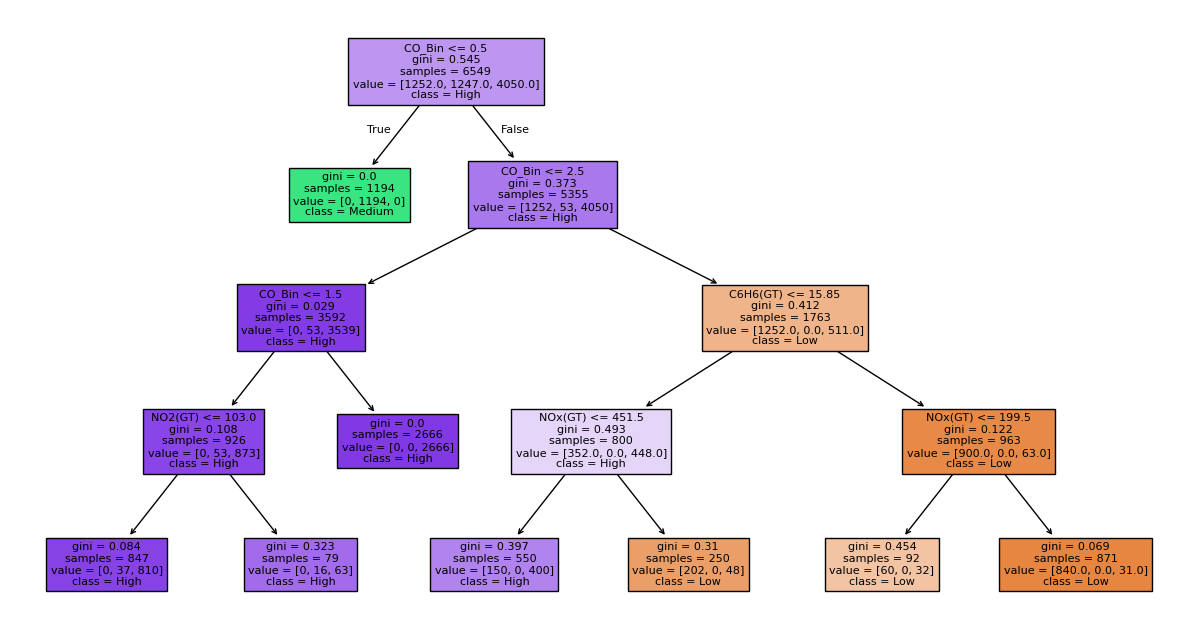

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
df_tree = df.dropna()
target = pd.cut(df_tree['CO(GT)'], bins=3, labels=['Low', 'Medium', 'High'])
X = df_tree.select_dtypes(include=np.number).drop('CO(GT)', axis=1)
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Visualize tree
plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=X.columns, class_names=['Low', 'Medium', 'High'], filled=True)
plt.show()


###Random Forest Algorithm

Random Forest Accuracy: 0.9622372639828999
              precision    recall  f1-score   support

        High       0.93      0.93      0.93       577
         Low       1.00      0.96      0.98       513
      Medium       0.96      0.98      0.97      1717

    accuracy                           0.96      2807
   macro avg       0.96      0.95      0.96      2807
weighted avg       0.96      0.96      0.96      2807



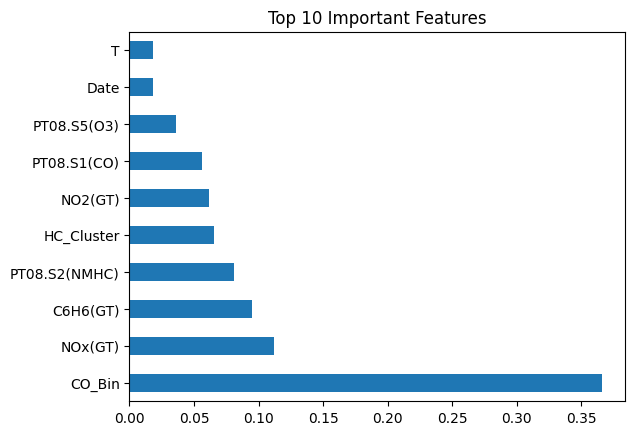

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', title="Top 10 Important Features")
plt.show()


###ANN


ANN Accuracy: 0.8649804061275383
              precision    recall  f1-score   support

        High       0.78      0.94      0.85       577
         Low       0.77      0.85      0.81       513
      Medium       0.94      0.84      0.89      1717

    accuracy                           0.86      2807
   macro avg       0.83      0.88      0.85      2807
weighted avg       0.88      0.86      0.87      2807



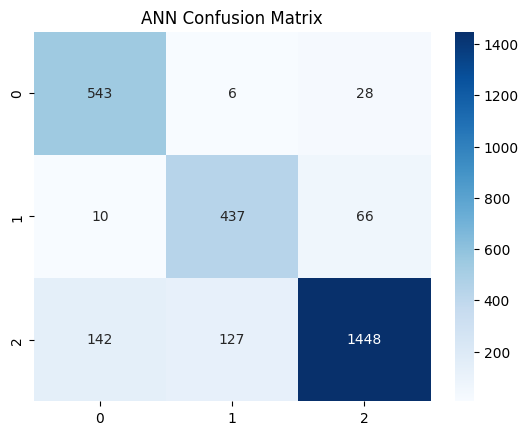

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Neural Network Model
ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, fmt='d', cmap='Blues')
plt.title("ANN Confusion Matrix")
plt.show()
